# 4. Modeling (LightGBM)

In [7]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import time
import warnings
warnings.filterwarnings('ignore')

## 4.1 Load Prepared Dataset

In [8]:
df = pd.read_csv('../Datasets/prepared_dataset.csv')

# Convert categorical columns to 'category' type
cat_features = ['BP_History', 'Medication', 'Family_History', 'Exercise_Level', 'Smoking_Status']
for col in cat_features:
    df[col] = df[col].astype('category')

X = df.drop('Has_Hypertension', axis=1)
y = df['Has_Hypertension']

## 4.2 LightGBM Training & Split Comparison
Kita akan membandingkan 3 skenario split data: 70-30, 80-20, dan 90-10, lalu mengukur waktu pelatihan serta akurasinya.

In [9]:
splits = [0.3, 0.2, 0.1]
split_names = ['70-30', '80-20', '90-10']
results = []
models = {}

for test_size, name in zip(splits, split_names):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
    
    model = lgb.LGBMClassifier(random_state=42)
    
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    
    training_time = end_time - start_time
    
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    results.append({
        'Split': name,
        'Training Time (s)': training_time,
        'Accuracy': accuracy
    })
    models[name] = {'model': model, 'X_test': X_test, 'y_test': y_test, 'y_pred': y_pred}

df_results = pd.DataFrame(results)
print("=== Perbandingan Skenario Split ===")
display(df_results)

[LightGBM] [Info] Number of positive: 722, number of negative: 667
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000137 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 449
[LightGBM] [Info] Number of data points in the train set: 1389, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.519798 -> initscore=0.079235
[LightGBM] [Info] Start training from score 0.079235
[LightGBM] [Info] Number of positive: 826, number of negative: 762
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000185 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 460
[LightGBM] [Info] Number of data points in the train set: 1588, number of used features: 10
[LightGBM] [Info] [binary:BoostF

,Split,Training Time (s),Accuracy
0,70-30,0.630820,0.984899
1,80-20,0.254823,0.977330
2,90-10,0.263081,0.979899


## 4.3 Evaluasi Model Terbaik (Skenario 80-20)
Untuk evaluasi dan tahapan SHAP lebih lanjut, kita simpan dan gunakan skenario standar 80-20.

In [10]:
best_model_info = models['80-20']
best_model = best_model_info['model']
X_test_best = best_model_info['X_test']
y_test_best = best_model_info['y_test']
y_pred_best = best_model_info['y_pred']
y_proba_best = best_model.predict_proba(X_test_best)[:, 1]

print('Classification Report (80-20):')
print(classification_report(y_test_best, y_pred_best))

print(f'ROC-AUC Score: {roc_auc_score(y_test_best, y_proba_best):.4f}')
print(f'Accuracy: {accuracy_score(y_test_best, y_pred_best):.4f}')

Classification Report (80-20):
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       191
           1       0.97      0.99      0.98       206

    accuracy                           0.98       397
   macro avg       0.98      0.98      0.98       397
weighted avg       0.98      0.98      0.98       397

ROC-AUC Score: 0.9980
Accuracy: 0.9773


### 4.3.1 Confusion Matrix (80-20)

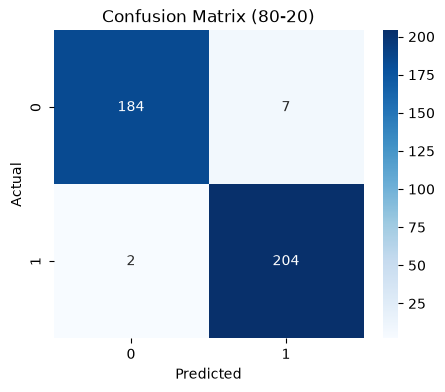

In [11]:
cm = confusion_matrix(y_test_best, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (80-20)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 4.4 Menyimpan Model

In [12]:
os.makedirs('../Models', exist_ok=True)
model_path = '../Models/lightgbm_model.pkl'
joblib.dump(best_model, model_path)
print(f'Model 80-20 berhasil disimpan di: {model_path}')

Model 80-20 berhasil disimpan di: ../Models/lightgbm_model.pkl
